c:\Users\ASUS\anaconda3\envs\genai_research\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Metadata records: 20


,chunk_id,lang,disease_name_en,disease_name_si
0,D001,en,Tarunya Pitika (Acne vulgaris),තරුණ්‍ය පිටිකා (මුඛදූෂිකා)
1,D001,si,Tarunya Pitika (Acne vulgaris),තරුණ්‍ය පිටිකා (මුඛදූෂිකා)
2,D002,en,Vicharchika (Eczema),විචර්චිකා (ඇක්සීමා)
3,D002,si,Vicharchika (Eczema),විචර්චිකා (ඇක්සීමා)
4,D003,en,Mashaka (Elevated Mole),මෂක (ඉහළට නෙරා ඇති ලපය)


ST vectors: 20
OpenAI vectors: 20
✅ OpenAI enabled


,query,model,Precision@K,Recall@K,MRR,nDCG@K
0,Oily skin with inflamed pimples and blackheads,SentenceTransformer,0.2,1.0,1.00,1.000000
1,Oily skin with inflamed pimples and blackheads,OpenAI Embeddings,0.2,1.0,1.00,1.000000
2,"Chronic itching with dry, cracked skin",SentenceTransformer,0.2,1.0,1.00,1.000000
3,"Chronic itching with dry, cracked skin",OpenAI Embeddings,0.2,1.0,1.00,1.000000
4,Raised dark mole on the skin,SentenceTransformer,0.2,1.0,1.00,1.000000
5,Raised dark mole on the skin,OpenAI Embeddings,0.2,1.0,1.00,1.000000
6,Painful red acne with pus-filled lesions,SentenceTransformer,0.2,1.0,1.00,1.000000
7,Painful red acne with pus-filled lesions,OpenAI Embeddings,0.2,1.0,0.50,0.630930
8,Severe skin dryness causing scaling and consta...,SentenceTransformer,0.2,1.0,1.00,1.000000
9,Severe skin dryness causing scaling and consta...,OpenAI Embeddings,0.2,1.0,1.00,1.000000


,Precision@K,Recall@K,MRR,nDCG@K
model,,,,
OpenAI Embeddings,0.211765,1.000000,0.867647,0.894158
SentenceTransformer,0.164706,0.764706,0.735294,0.742996


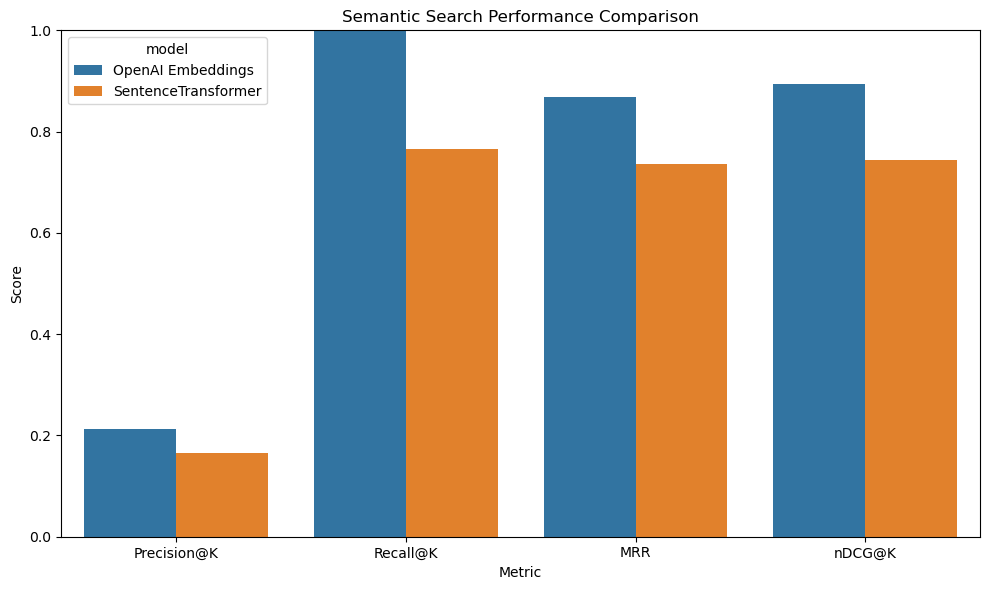

In [1]:
# -------------------------------------------------------
# 07_evaluation.ipynb
# Evaluation of Semantic Search Performance
# -------------------------------------------------------

import numpy as np
import pandas as pd
import faiss
import yaml
import os
from pathlib import Path
from sentence_transformers import SentenceTransformer
from openai import OpenAI
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------------------------------
# Load config
# -------------------------------------------------------
with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

DATA_DIR = Path(config.get("paths", {}).get("data", "data"))
EMB_DIR = Path(config.get("paths", {}).get("embeddings", "embeddings"))
INDEX_DIR = Path(config.get("paths", {}).get("indices", "indices"))

MODEL_ST = config.get("models", {}).get(
    "sentence_transformer", "all-MiniLM-L6-v2"
)

OPENAI_MODEL = config.get("models", {}).get(
    "openai_embedding", "text-embedding-3-small"
)

TOP_K = config.get("retrieval", {}).get("top_k", 5)


# -------------------------------------------------------
# Load metadata
# -------------------------------------------------------
META_JSON = EMB_DIR / "metadata.json"
metadata_df = pd.read_json(META_JSON)

print("Metadata records:", len(metadata_df))
display(metadata_df.head())


# -------------------------------------------------------
# Load FAISS indices
# -------------------------------------------------------
index_st = faiss.read_index(str(INDEX_DIR / "faiss_index_st.index"))
index_oa = faiss.read_index(str(INDEX_DIR / "faiss_index_openai.index"))

print("ST vectors:", index_st.ntotal)
print("OpenAI vectors:", index_oa.ntotal)


# -------------------------------------------------------
# Load models
# -------------------------------------------------------
st_model = SentenceTransformer(MODEL_ST)

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = OpenAI(api_key=api_key)
    OPENAI_ENABLED = True
    print("✅ OpenAI enabled")
else:
    client = None
    OPENAI_ENABLED = False
    print("⚠️ OpenAI disabled")


# -------------------------------------------------------
# Embedding + Retrieval
# -------------------------------------------------------
def embed_query_st(query):
    vec = st_model.encode([query], convert_to_numpy=True)
    return vec.astype("float32")

def embed_query_openai(query):
    if not OPENAI_ENABLED:
        raise RuntimeError("OpenAI not enabled")

    resp = client.embeddings.create(
        model=OPENAI_MODEL,
        input=query
    )
    vec = np.array(resp.data[0].embedding, dtype="float32")
    return vec.reshape(1, -1)

def semantic_search(query, model_type="st", top_k=5):
    if model_type == "st":
        query_vec = embed_query_st(query)
        index = index_st
    elif model_type == "openai":
        if not OPENAI_ENABLED:
            return []
        query_vec = embed_query_openai(query)
        index = index_oa
    else:
        raise ValueError("Invalid model type")

    distances, indices = index.search(query_vec, top_k)
    retrieved_ids = metadata_df.iloc[indices[0]]["chunk_id"].tolist()
    return retrieved_ids


# -------------------------------------------------------
# Ground truth evaluation queries
# -------------------------------------------------------
evaluation_queries = [

    # English
    {"query": "Oily skin with inflamed pimples and blackheads", "relevant_docs": ["D001"]},
    {"query": "Chronic itching with dry, cracked skin", "relevant_docs": ["D002"]},
    {"query": "Raised dark mole on the skin", "relevant_docs": ["D003"]},
    {"query": "Painful red acne with pus-filled lesions", "relevant_docs": ["D001"]},
    {"query": "Severe skin dryness causing scaling and constant itching", "relevant_docs": ["D002"]},
    {"query": "Irregular shaped mole with dark pigmentation", "relevant_docs": ["D003"]},

    # Ayurveda
    {"query": "Pitta imbalance causing inflamed acne and burning sensation", "relevant_docs": ["D001"]},
    {"query": "Vata-related skin dryness with cracking and itching", "relevant_docs": ["D002"]},
    {"query": "Abnormal growth on skin with discoloration and size increase", "relevant_docs": ["D003"]},

    # Sinhala
    {"query": "මුහුණේ තෙල් සහිත කුරුලෑ සහ දැවිල්ල", "relevant_docs": ["D001"]},
    {"query": "තද කුරුලෑ, වේදනාව සහ පූරක සහිත මුහුණ", "relevant_docs": ["D001"]},
    {"query": "වියළි සම, කැකුළු සහ තද කැරකීම", "relevant_docs": ["D002"]},
    {"query": "කලු පැහැති අසාමාන්‍ය තිලිනයක් සම මත", "relevant_docs": ["D003"]},

    # Ambiguous
    {"query": "Itchy red bumps appearing on oily skin", "relevant_docs": ["D001", "D002"]},
    {"query": "Dark skin mark with mild itching and slow growth", "relevant_docs": ["D003"]},

    # Early vs advanced
    {"query": "Small painless mole noticed recently", "relevant_docs": ["D003"]},
    {"query": "Long-term acne scars with recurring inflammation", "relevant_docs": ["D001"]},
]


# -------------------------------------------------------
# Evaluation metrics
# -------------------------------------------------------
def precision_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / k

def recall_at_k(retrieved, relevant, k):
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

def mean_reciprocal_rank(retrieved, relevant):
    for i, doc_id in enumerate(retrieved):
        if doc_id in relevant:
            return 1 / (i + 1)
    return 0.0

def dcg_at_k(retrieved, relevant, k):
    score = 0.0
    for i, doc_id in enumerate(retrieved[:k]):
        if doc_id in relevant:
            score += 1 / np.log2(i + 2)
    return score

def ndcg_at_k(retrieved, relevant, k):
    dcg = dcg_at_k(retrieved, relevant, k)
    ideal_dcg = dcg_at_k(relevant, relevant, k)
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0


# -------------------------------------------------------
# Run evaluation
# -------------------------------------------------------
results = []

for item in evaluation_queries:
    query = item["query"]
    relevant = item["relevant_docs"]

    retrieved_st = semantic_search(query, "st", TOP_K)
    results.append({
        "query": query,
        "model": "SentenceTransformer",
        "Precision@K": precision_at_k(retrieved_st, relevant, TOP_K),
        "Recall@K": recall_at_k(retrieved_st, relevant, TOP_K),
        "MRR": mean_reciprocal_rank(retrieved_st, relevant),
        "nDCG@K": ndcg_at_k(retrieved_st, relevant, TOP_K)
    })

    if OPENAI_ENABLED:
        retrieved_oa = semantic_search(query, "openai", TOP_K)
        results.append({
            "query": query,
            "model": "OpenAI Embeddings",
            "Precision@K": precision_at_k(retrieved_oa, relevant, TOP_K),
            "Recall@K": recall_at_k(retrieved_oa, relevant, TOP_K),
            "MRR": mean_reciprocal_rank(retrieved_oa, relevant),
            "nDCG@K": ndcg_at_k(retrieved_oa, relevant, TOP_K)
        })


df_results = pd.DataFrame(results)
display(df_results)


# -------------------------------------------------------
# Summary + Visualization
# -------------------------------------------------------
summary = df_results.groupby("model")[["Precision@K", "Recall@K", "MRR", "nDCG@K"]].mean()
display(summary)

plot_df = summary.reset_index().melt(
    id_vars="model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="model")
plt.title("Semantic Search Performance Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
